In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model
from sklearn.model_selection import train_test_split

In [2]:
#Exercise 7.01 - Comparing Predicitions by Linear and Logistic Regression

#Load in the data
data = pd.read_csv('https://raw.githubusercontent.com/johnson80245/python/refs/heads/main/csvs/DS%20for%20marketing%20analytics%20data/Chapter07/Exercise7.01/Shill_Bidding_Dataset.csv')
data.head()

#Drop Record ID, Auction ID, Bidder ID
data.drop(["Record_ID","Auction_ID","Bidder_ID"], 
          axis = 1, 
          inplace = True)

data.head()

#Split into training and test data sticking to a test size 30%
X = data.drop('Class',
              axis = 1)
y = data['Class']
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.3,
                                                    random_state = 1,
                                                    stratify = y)

#Print the size of the training and test data 
print("Training dataset size: {}, Testing dataset size: {}".format(X_train.shape,X_test.shape))

#Fit the model using linear regression
linear = linear_model.LinearRegression()
linear.fit(X_train, y_train)

#Predict on the first 10 test data points 
linear.predict(X_test)[:10]

#Check actual values 
y_test[:10].values

#Evaluate the score of the linear regreassion model on the training and testing
print("Score on training dataset: {} " 
      "Score on testing dataset: {}" 
        .format(linear.score(X_train, y_train),
                linear.score(X_test, y_test)))

#Compare with logistic regression 
logit = linear_model.LogisticRegression()
logit.fit(X_train, y_train)

#Predict on the first 10 
print(logit.predict(X_test)[:10])

#Check actual values
print(y_test[:10].values)

#Check Scores 
print("Score on training dataset: {} " 
      "Score on testing dataset: {}" 
        .format(logit.score(X_train, y_train),
                logit.score(X_test, y_test)))

Training dataset size: (4424, 9), Testing dataset size: (1897, 9)
Score on training dataset: 0.8166836356918418 Score on testing dataset: 0.8119909602893054
[0 0 0 0 0 1 0 0 0 0]
[0 0 0 0 0 1 0 0 0 0]
Score on training dataset: 0.9794303797468354 Score on testing dataset: 0.9715340010542962


<Axes: >

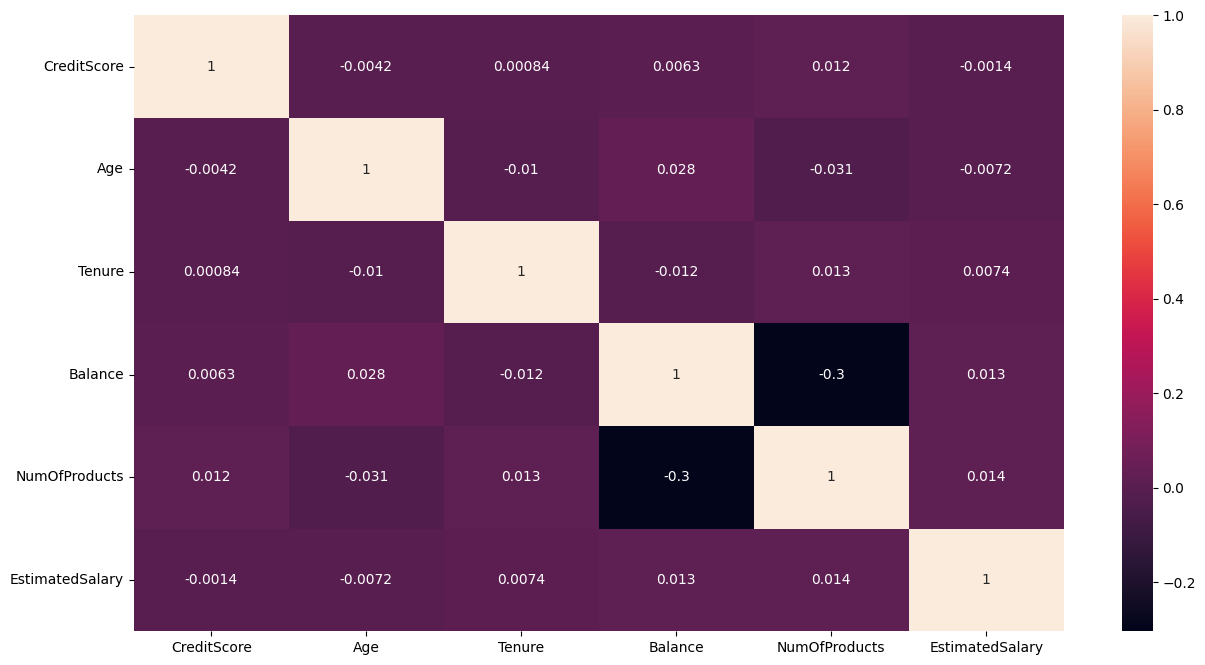

In [ ]:
#Churn Case Study 

#Exercise 7.02 Obtaining the data 
data = pd.read_csv('https://raw.githubusercontent.com/johnson80245/python/refs/heads/main/csvs/DS%20for%20marketing%20analytics%20data/Chapter07/Exercise7.02/Churn_Modelling.csv')
data.head()
len(data)
data.shape


#Exercise 7.03 Imputing Missing Values
#Check missing values 
data.isnull().values.any() # Returns TRUE

#Look at missing values columns 
data.isnull().any()

#Using describe to view age and estimated salary
data[["EstimatedSalary","Age"]].describe()

#Using describe across the data frame
data.describe()

#Check count of 1 & 0 of has card
data['HasCrCard'].value_counts()

#Check total missing values 
data.isnull().sum()

#Check the percentage of missing values
round(data.isnull().sum()/len(data)*100,2)

#Check data type of missing columns 
data[["Gender", "Age", "EstimatedSalary"]].dtypes


#Impute missing values for estimated salary using the mean 
mean_value = data['EstimatedSalary'].mean()
data['EstimatedSalary'] = data["EstimatedSalary"].fillna(mean_value)

#Impute missing values for gender using idmax
data['Gender'] = data['Gender'].fillna(data['Gender'].value_counts().idxmax())

#Impute missing values for age using the mode 
data['Age'].mode()
mode_value = data['Age'].mode()
data['Age'] = data['Age'].fillna(mode_value[0])

#Check that missing values are filled
data.isnull().any()



#Exercise 7.04 Renaming Columns & Changing datatypes

data = data.rename(columns = {'CredRate' : 'CreditScore',
                              'ActMem' : 'IsActiveMember',
                              'Prod Number' : 'NumOfProducts',
                              'Exited' : 'Churn'})

data.columns

#Drop Customer ID and move Churn to the right 
data.drop(labels = ['CustomerId'],
          axis = 1, 
          inplace = True)

column_churn = data['Churn']
data.drop(labels = 'Churn',
          axis = 1, 
          inplace = True)
data.insert(len(data.columns),
            'Churn',
            column_churn.values)
data.columns

#Change certain columns to categorical values
cat_cols = [['Geography','Gender','HasCrCard','Churn','IsActiveMember']]
for column in cat_cols:
    data[column] = data[column].astype('category')
data.dtypes


#Exercise 7.05 Obtaining the Statistical Overview and Correlation Plot

#Inspect the target variable
data['Churn'].value_counts()

#Inspect the percentage of customers who churned
data['Churn'].value_counts(1) * 100

#Inspect the percentage of customers with credit cards
data['HasCrCard'].value_counts(1) * 100

#Look at statistical overview
data.describe()

#Look at statistical data by target variable
data.groupby('Churn',observed = False)[['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary']].mean()
data.groupby('Churn',observed = False)[['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary']].median()

#Using seaborn for visualization plot 
corr = data.corr(numeric_only = True)
plt.figure(figsize=(15,8))
sns.heatmap(corr,
            xticklabels = corr.columns.values,
            yticklabels = corr.columns.values,
            annot = True)



#Exercise 7.06 Perfrorming Exploratory Data Analysis

